# 05 · Model Evaluation

## 1. Objective
Score the three tuned models on the **held-out test set (80 patients)** and compare them with medical-classification metrics. The final model was already chosen from cross-validation (`reports/selection.json`), so nothing here changes that choice. **Cross-validation results (notebook 04) and test results (this notebook) are kept separate.**

> ⚠️ *Educational demonstration - not for medical diagnosis or clinical decisions.*

## Metrics in plain language
Let CKD = "positive". **TP** = CKD predicted CKD · **TN** = healthy predicted healthy · **FP** = healthy wrongly flagged CKD · **FN** = CKD patient missed.

| Metric | Formula | Question it answers |
|---|---|---|
| Accuracy | (TP+TN)/all | Overall, how often is the model right? (can mislead when classes are imbalanced) |
| Precision | TP/(TP+FP) | Of patients predicted CKD, how many really were? |
| Recall = Sensitivity | TP/(TP+FN) | Of patients who really have CKD, how many did we catch? |
| Specificity | TN/(TN+FP) | Of patients without CKD, how many did we correctly clear? |
| F1 | 2PR/(P+R) | Balance between precision and recall |
| ROC-AUC | area under TPR-vs-FPR curve | How well does the model *rank* CKD above non-CKD across all thresholds? (0.5 = coin flip, 1 = perfect) |

**Why false negatives deserve attention:** a missed CKD case (FN) can mean delayed follow-up, which is usually costlier than an extra confirmatory test (FP). But maximising recall is *not* universally correct: pushing it up costs precision, i.e. more false alarms, anxiety and testing. The right balance depends on the clinical use case, which this educational project does not have.

**Threshold:** models output a probability; the default cut-off is 0.5. Lowering it catches more CKD (↑recall, ↑FP, ↓FN); raising it does the opposite (↑precision, ↓recall).

## 2. Imports

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # make `src` importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
def savefig(name): plt.savefig(FIG / name, bbox_inches="tight", dpi=150)

In [2]:
from src.evaluate import (load_models, load_selection, get_data, evaluate_on_test, plot_confusion_matrices,
                          plot_roc_pr, threshold_analysis, plot_threshold_curves)
models, sel = load_models(), load_selection()
X_train, X_test, y_train, y_test = get_data()
print("Final model selected from CV (before this notebook):", sel["final_model"])
print("Test set:", X_test.shape, "| CKD share:", round(y_test.mean(), 3))

Final model selected from CV (before this notebook): Logistic Regression
Test set: (80, 24) | CKD share: 0.625


## 3. Test-set results (default threshold 0.50)
This is the single, final test evaluation - no tuning follows.

In [3]:
results = evaluate_on_test(models, X_test, y_test)
results.round(4).to_csv(Path.cwd().parent / "reports" / "model_results.csv")
display(results[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Specificity"]].round(4))
display(results[["TN", "FP", "FN", "TP"]].astype(int))

,Accuracy,Precision,Recall,F1,ROC-AUC,Specificity
Model,,,,,,
Logistic Regression,0.9750,1.0,0.96,0.9796,1.00,1.0
Decision Tree,0.9875,1.0,0.98,0.9899,0.99,1.0
Random Forest,1.0000,1.0,1.00,1.0000,1.00,1.0


,TN,FP,FN,TP
Model,,,,
Logistic Regression,30,0,2,48
Decision Tree,30,0,1,49
Random Forest,30,0,0,50


## 4. Confusion matrices
Top-left **TN**: healthy correctly cleared · top-right **FP**: healthy flagged CKD · bottom-left **FN**: CKD patient missed · bottom-right **TP**: CKD correctly found.

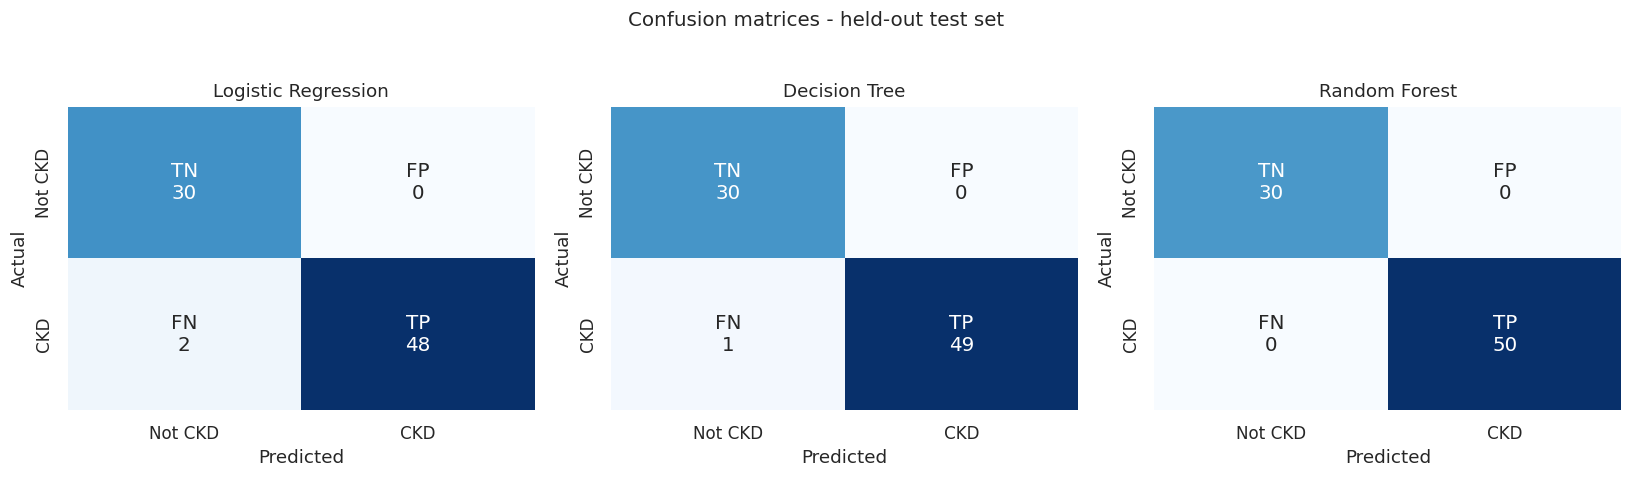

In [4]:
plot_confusion_matrices(models, X_test, y_test); plt.show()

## 5. ROC and Precision-Recall curves

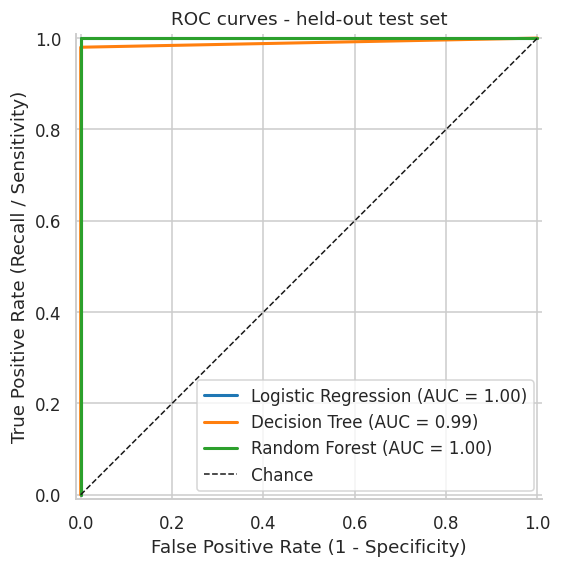

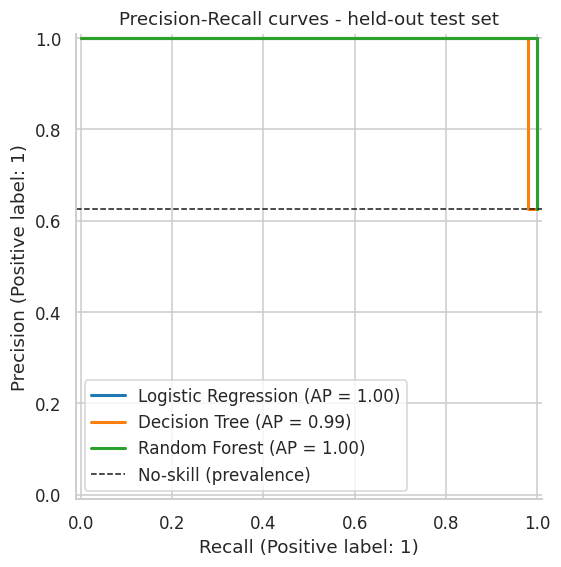

In [5]:
plot_roc_pr(models, X_test, y_test); plt.show()

The ROC curve plots recall (TPR) against the false-positive rate as the threshold moves; the closer to the top-left corner the better. The **Precision-Recall** curve is more informative when the positive class matters most; the dashed line is the "no-skill" precision (= CKD prevalence). Curves that hug the top-right corner keep high precision *and* high recall.

## 6. Threshold analysis
To look at thresholds **without using the test set**, we use *out-of-fold* predictions on the training set (each patient is scored by a model that never saw them).

Recall                                       Precision                                  
Model     Decision Tree Logistic Regression Random Forest Decision Tree Logistic Regression Random Forest
Threshold                                                                                                
0.10               0.99                1.00          1.00          0.98               0.980         0.930
0.25               0.99                1.00          1.00          0.98               0.980         0.985
0.50               0.99                1.00          1.00          0.98               0.995         0.990
0.75               0.99                0.97          0.97          0.98               1.000         1.000
0.90               0.99                0.93          0.88          0.98               1.000         1.000

FN                                              FP                                  
Model     Decision Tree Logistic Regression Random Forest Decision Tree Logistic Regression Random Forest
Threshold                                                                                                
0.10                  2                   0             0             4                   4            15
0.25                  2                   0             0             4                   4             3
0.50                  2                   0             0             4                   1             2
0.75                  2                   6             6             4                   0             0
0.90                  2                  14            24             4                   0             0

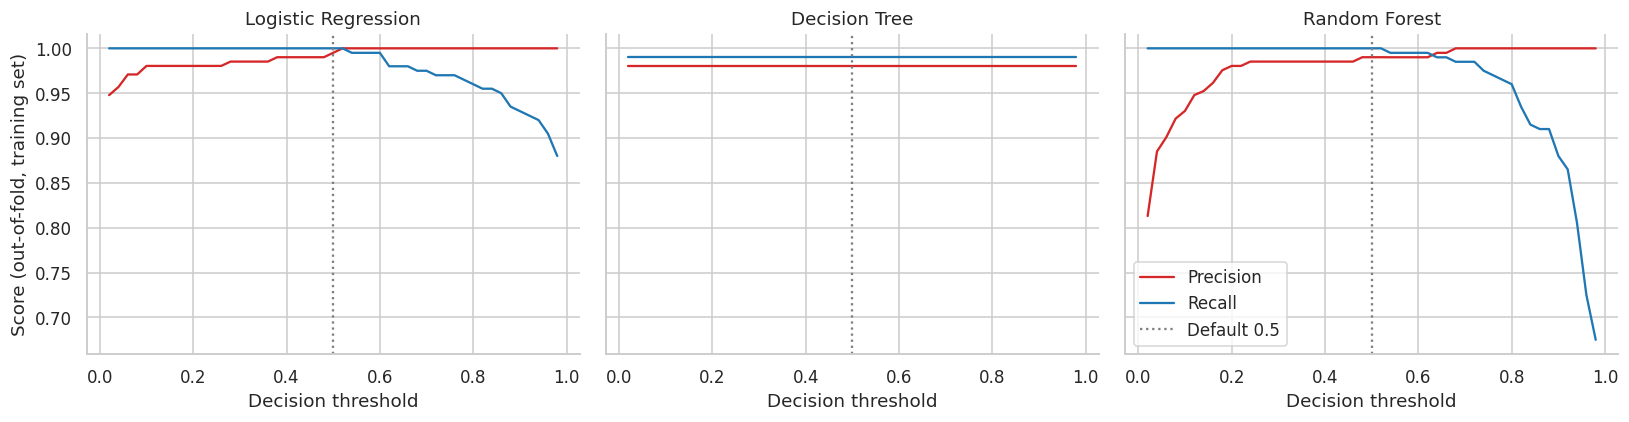

In [6]:
thr = threshold_analysis(models, X_train, y_train)
display(thr.pivot(index="Threshold", columns="Model", values=["Recall", "Precision"]).round(3))
display(thr.pivot(index="Threshold", columns="Model", values=["FN", "FP"]))
plot_threshold_curves(models, X_train, y_train); plt.show()

Reading the table: as the threshold rises, **FN goes up and recall falls**, while FP goes down and precision rises; as it falls, the reverse. Random Forest probabilities are the most threshold-sensitive at the extremes. We keep 0.50 - choosing a different threshold would need a clinical rationale (relative cost of FN vs FP) and ideally calibrated probabilities; it is listed as future work.

## 7. Model comparison and selection discussion
CV and test tables are shown side by side but **never mixed**.

In [7]:
cv = pd.read_csv(Path.cwd().parent / "reports" / "cv_results.csv")
t = cv[cv.stage == "Tuned"].set_index("model")
comp = pd.DataFrame({
    "CV recall (mean±std)": t.recall_mean.round(3).astype(str) + " ± " + t.recall_std.round(3).astype(str),
    "CV F1 (mean±std)": t.f1_mean.round(3).astype(str) + " ± " + t.f1_std.round(3).astype(str),
    "TEST recall": results["Recall"].round(3), "TEST precision": results["Precision"].round(3),
    "TEST FN": results["FN"].astype(int), "TEST FP": results["FP"].astype(int)})
display(comp)
print("Selected from CV:", sel["final_model"], "|", sel["rationale"])

,CV recall (mean±std),CV F1 (mean±std),TEST recall,TEST precision,TEST FN,TEST FP
Logistic Regression,1.0 ± 0.0,0.998 ± 0.005,0.96,1.0,2,0
Decision Tree,0.99 ± 0.012,0.985 ± 0.014,0.98,1.0,1,0
Random Forest,1.0 ± 0.0,0.995 ± 0.006,1.00,1.0,0,0


Selected from CV: Logistic Regression | Ranked by CV recall, then CV F1, then CV ROC-AUC (3 d.p.), then interpretability. Logistic Regression: recall=1.000, F1=0.998, ROC-AUC=1.000.


### Trade-offs
- **Logistic Regression** - simplest, fully interpretable (coefficients / odds ratios), fast, and it was the top-ranked model in CV under our stated rule. Its 2 missed CKD cases on the test set are a reminder that a linear boundary can miss patients with mixed or incomplete profiles.
- **Random Forest** - the most complex and least transparent, but the most flexible; it scored best on this particular test set (fewest errors). However the test set holds only 80 patients, so **one patient is 1.25 percentage points**: the difference between models here is 1-2 patients and is *not* statistically meaningful.
- **Decision Tree** - highly interpretable, but the most variable in CV, and it has only a coarse probability output (leaf proportions), so its ROC-AUC is lower.

**Important:** we do **not** switch the final model because Random Forest looked better on the test set - doing so would be tuning on the test set. We report the pre-selected model's test result honestly and note that the models are practically comparable.

**Sanity caution:** near-perfect scores on this dataset are well known. The data is small, single-source, and its missing-value pattern is correlated with the label (notebook 02). These numbers do **not** imply real-world performance.

## 10. Conclusions
- Final test results are reported once for all models; final model = the CV-selected model.
- Precision and specificity are perfect for all three on this test set; differences come only from a few missed CKD cases.
- Everything must be read with an 80-row test set in mind.